# ViT neural net with pytorch (and pytorch lightning ⚡)


* We will be training a VIT on a subset tiny image dataset


In [ ]:
# import standard PyTorch modules
import pytorch_lightning as pl
import pdb
import lightning
import torchmetrics
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

# import torchvision module to handle image manipulation
import torchvision
import torchvision.transforms as transforms

# Import other useful libraries
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from lightning.pytorch import seed_everything

seed_everything(2026, workers=True)

Seed set to 2026


2026

In [3]:
# Check PyTorch versions
print(torch.__version__)
print(torchvision.__version__)

2.10.0+cpu
0.25.0+cpu


In [4]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
device

'cpu'

## Load the data and visualize it

In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# ImageFolder STANDARD
train_dataset = datasets.ImageFolder(
    root="./generated_datasets/texture_dataset/train",
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    root="./generated_datasets/texture_dataset/test",
    transform=val_transform
)

DATA = "texture"
num_classes = 5

In [6]:
num_workers = 12

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=num_workers, persistent_workers=True, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=24, shuffle=False, num_workers=num_workers, persistent_workers=True, pin_memory=True)


In [7]:
# import numpy as np
# import matplotlib.pyplot as plt

# def show_images_grid(images):  # ← Pour GRID (batch)
#     """Affiche batch d'images normalisées"""
#     images = torchvision.utils.make_grid(images)  # [3, H*3, W*3]
#     images = images
#     images = torch.clamp(images, 0, 1)
#     npimg = images.numpy().transpose((1, 2, 0))
#     plt.figure(figsize=(8, 8))
#     plt.imshow(npimg)
#     plt.axis('off')
#     plt.show()

# # ✅ USAGE CORRECT
# train_iter = iter(train_loader)
# images, labels = next(train_iter)  # [B,3,64,64] + labels
# show_images_grid(images)  # Affiche 64 images en grille 8x8

In [8]:
# class_mapping = {
#     0: "fish",
#     1: "umbrella",
#     2: "cup",
#     3: "mountain",
#     4: "beach",
#     5: "thatched_roof",
#     6: "merrygoround",
#     7: "cabbage",
#     8: "tart",
#     9: "staircase"
# }

# np.set_printoptions(linewidth=120)
# np.array([class_mapping[labels[j].item()] for j in range(64)]).reshape(8, 8)

## A ViT architecture using pytorch-lightning

Since we will use pytorch-lightning, our class needs to inherit from pl.LightningModule

In [7]:
class ConvMLP(nn.Module):
    def __init__(self, dim, mlp_ratio=4):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * mlp_ratio)
        self.dwconv = nn.Conv2d(dim * mlp_ratio, dim * mlp_ratio, 3, 1, 1, groups=dim * mlp_ratio)
        self.fc2 = nn.Linear(dim * mlp_ratio, dim)
        self.act = nn.GELU()

    def forward(self, x, H, W):  # H,W = forme spatiale des patches
        x = self.fc1(x)
        x = self.act(x)
        B, N, C = x.shape
        x = x.transpose(1,2).reshape(B, C, H, W)  # Remettre en 2D
        x = self.dwconv(x)
        x = x.flatten(2).transpose(1,2)
        x = self.fc2(x)
        return x

class DHVTBlock(nn.Module):
    def __init__(self, dim, num_heads=8, mlp_ratio=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = ConvMLP(dim, mlp_ratio)

    def forward(self, x, H, W):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x), H, W)
        return x

In [8]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
import torchmetrics
from torchmetrics.classification import MulticlassConfusionMatrix
from torch.optim.lr_scheduler import ReduceLROnPlateau


class ConvMLP(nn.Module):
    def __init__(self, dim, mlp_ratio=4, dropout=0.25):
        super().__init__()
        hidden_dim = dim * mlp_ratio
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.act = nn.GELU()
        self.dwconv = nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, stride=1, padding=1, groups=hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, H, W):
        x = self.fc1(x)
        x = self.act(x)

        cls_token = x[:, :1, :]
        feat_tokens = x[:, 1:, :]

        B, N, C = feat_tokens.shape
        feat_tokens = feat_tokens.transpose(1, 2).reshape(B, C, H, W)
        feat_tokens = self.dwconv(feat_tokens)
        feat_tokens = feat_tokens.flatten(2).transpose(1, 2)

        x = torch.cat([cls_token, feat_tokens], dim=1)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class DHVTBlock(nn.Module):
    def __init__(self, dim, num_heads=8, mlp_ratio=4, dropout=0.25):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = ConvMLP(dim, mlp_ratio=mlp_ratio, dropout=dropout)

    def forward(self, x, H, W):
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x), H, W)
        return x


class VisionTransformer(pl.LightningModule):
    def __init__(self, num_classes=10, confmat_log_path="confusion_matrices.json", emb_size=192, mlp_ratio=4):
        super(VisionTransformer, self).__init__()

        self.num_classes = num_classes
        self.confmat_log_path = confmat_log_path
        self.current_train_confmat = None

        self.patch_embed = nn.Sequential(
            nn.Conv2d(3, emb_size // 4, kernel_size=3, stride=2, padding=1),
            nn.GELU(),
            nn.Conv2d(emb_size // 4, emb_size // 2, kernel_size=3, stride=2, padding=1),
            nn.GELU(),
            nn.Conv2d(emb_size // 2, emb_size, kernel_size=3, stride=2, padding=1),
            nn.GELU()
        )

        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_size))
        self.pos_embed = nn.Parameter(torch.randn(1, 65, emb_size))

        self.blocks = nn.ModuleList([
            DHVTBlock(emb_size, 8, mlp_ratio) for _ in range(4)
        ])
        self.norm = nn.LayerNorm(emb_size)

        self.head = nn.Linear(in_features=emb_size, out_features=num_classes)

        self.accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=num_classes)

        self.train_confmat = MulticlassConfusionMatrix(num_classes=num_classes)
        self.val_confmat = MulticlassConfusionMatrix(num_classes=num_classes)

        self.train_loss = 0.0
        self.valid_loss = 0.0

    def encoder(self, x):
        B = x.shape[0]
        patches = self.patch_embed(x).flatten(2).transpose(1, 2)
        H = W = int(patches.shape[1] ** 0.5)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, patches], dim=1)
        x = x + self.pos_embed[:, :x.shape[1], :]
        for block in self.blocks:
            x = block(x, H, W)
        x = self.norm(x)
        return x[:, 0]

    def classifier(self, x):
        out = self.head(x)
        return out

    def forward(self, x):
        features = self.encoder(x)
        logits = self.classifier(features)
        return logits

    def _step_util(self, batch, batch_idx, step_type):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)

        acc = self.accuracy(preds, y)

        self.log(f"{step_type}_loss", loss, on_step=False, on_epoch=True, prog_bar=True, logger=True)
        self.log(f"{step_type}_acc", acc, on_step=False, on_epoch=True, prog_bar=True, logger=True)

        if step_type == "train":
            self.train_confmat.update(preds, y)
            self.train_loss += loss.detach().item()
        elif step_type == "valid":
            self.val_confmat.update(preds, y)
            self.valid_loss += loss.detach().item()

        return loss

    def training_step(self, batch, batch_idx):
        return self._step_util(batch, batch_idx, "train")

    def validation_step(self, batch, batch_idx):
        return self._step_util(batch, batch_idx, "valid")

    def _get_current_lr(self):
        return self.trainer.optimizers[0].param_groups[0]["lr"]

    def _append_epoch_to_json(self, epoch, train_loss, valid_loss, train_cm, val_cm):
        entry = {
            "epoch": int(epoch),
            "train_loss": round(float(train_loss), 2),
            "valid_loss": round(float(valid_loss), 2),
            "train": train_cm.cpu().tolist(),
            "val": val_cm.cpu().tolist()
        }

        if os.path.exists(self.confmat_log_path):
            with open(self.confmat_log_path, "r", encoding="utf-8") as f:
                try:
                    data = json.load(f)
                except json.JSONDecodeError:
                    data = []
        else:
            data = []

        data.append(entry)

        with open(self.confmat_log_path, "w", encoding="utf-8") as f:
            json.dump(data, f, indent=4)

    def on_train_epoch_end(self):
        lr = self._get_current_lr()
        self.log("learning_rate", lr, on_step=False, on_epoch=True, prog_bar=True, logger=True)

        self.current_train_confmat = self.train_confmat.compute().detach().cpu()
        self.train_confmat.reset()

    def on_validation_epoch_end(self):
        val_cm = self.val_confmat.compute().detach().cpu()

        if self.current_train_confmat is not None:
            self._append_epoch_to_json(
                epoch=self.current_epoch,
                train_loss=self.train_loss,
                valid_loss=self.valid_loss,
                train_cm=self.current_train_confmat,
                val_cm=val_cm
            )

        self.val_confmat.reset()
        self.current_train_confmat = None
        self.train_loss = 0.0
        self.valid_loss = 0.0

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=1e-4, weight_decay=1e-2)
        return optimizer

**Pro tip.** When coding and debugging your architecture, don't use print statements to check the sizes of input / output tensors for instance. Use pdb (python debbuger) by writing the line
```python
import pdb; pdb.set_trace()
```
at the place where you want to check stuff

In [9]:
confmat_log_path = "confusion_matrices_" + DATA + ".json"
net = VisionTransformer(num_classes = num_classes, confmat_log_path=confmat_log_path)
print(net)

VisionTransformer(
  (patch_embed): Sequential(
    (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): GELU(approximate='none')
    (2): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): GELU(approximate='none')
    (4): Conv2d(96, 192, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): GELU(approximate='none')
  )
  (blocks): ModuleList(
    (0-3): 4 x DHVTBlock(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
      )
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (mlp): ConvMLP(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (dwconv): Conv2d(768, 768, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=768)
        (fc2): Linear(in_features=768, out_features=192, bias=Tru

**Pro tip.** Pytorch lighting proposes many very convenient flags to try and debug before testing. For instance, `fast_dev_run` runs some training and validation steps in order to check that everyting works.

## Train for some epochs


In [12]:
MAX_EPOCHS = 100

trainer = pl.Trainer(max_epochs=MAX_EPOCHS,
                     accelerator="auto",
                     devices="auto")

trainer.fit(net, train_dataloaders=train_loader, val_dataloaders=valid_loader)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
c:\Users\Yvan\Desktop\UPC\Deep Learning\TP\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpo

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Yvan\Desktop\UPC\Deep Learning\TP\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 99: 100%|██████████| 55/55 [00:03<00:00, 14.82it/s, v_num=44, valid_loss=2.420, valid_acc=0.547, train_loss=0.154, train_acc=0.946, learning_rate=0.0001]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 55/55 [00:03<00:00, 14.18it/s, v_num=44, valid_loss=2.420, valid_acc=0.547, train_loss=0.154, train_acc=0.946, learning_rate=0.0001]


In [13]:
trainer.save_checkpoint("ViT_modele_" + DATA + ".ckpt")

`weights_only` was not set, defaulting to `False`.


In [14]:
from torchmetrics.classification import MulticlassConfusionMatrix
import torch

metric = MulticlassConfusionMatrix(num_classes=num_classes)

if DATA in ("all", "texture"):
    test_dataset_texture = datasets.ImageFolder(
        root="./datasets_split/test/texture",
        transform=transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ])
    )

    test_loader_texture = DataLoader(test_dataset_texture, batch_size=64, shuffle=True, num_workers=num_workers, persistent_workers=True, pin_memory=True)

    net.eval()
    with torch.no_grad():
        for x, y in test_loader_texture:

            logits = net(x)
            preds = torch.argmax(logits, dim=1)
            metric.update(preds, y)

    cm_text = metric.compute()
    metric.reset()



if DATA in ("all", "long_range"):
    test_dataset_long_range = datasets.ImageFolder(
        root="./datasets_split/test/long_range",
        transform=transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ])
    )

    test_loader_long_range = DataLoader(test_dataset_long_range, batch_size=64, shuffle=True, num_workers=num_workers, persistent_workers=True, pin_memory=True)

    with torch.no_grad():
        for x, y in test_loader_long_range:

            logits = net(x)
            preds = torch.argmax(logits, dim=1)
            metric.update(preds, y)

    cm_long = metric.compute()


In [15]:
data = {}

# Texture
if DATA in ("all", "texture"):
    data["texture_confusion_matrix"] = cm_text.tolist()
    cm_text

In [16]:
# Long range
if DATA in ("all", "long_range"):
    data["long_range_confusion_matrix"] = cm_long.tolist()
    cm_long

In [17]:

with open("test_confusion_matrix_" +DATA+ ".json", "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2)

# Analyse des performances des modèles

## 1 Métriques et matrices de confusion

In [ ]:

print("VIT - texture")

with open("confusion_matrices_texture.json") as f:
    data = json.load(f)

# Trouver la meilleure epoch selon val accuracy
best_acc, best_cm, best_epoch = 0, None, None
for d in data:
    cm = np.array(d["val"])
    acc = cm.diagonal().sum() / cm.sum()
    if acc > best_acc:
        best_acc, best_cm, best_epoch = acc, cm, d["epoch"]

print(f"Meilleure epoch : {best_epoch}  |  val accuracy : {best_acc:.4f}\n")

# Métriques par classe
n = best_cm.shape[0]
precisions, recalls, f1s = [], [], []

for i in range(n):
    tp = best_cm[i, i]
    fp = best_cm[:, i].sum() - tp
    fn = best_cm[i, :].sum() - tp
    p  = tp / (tp + fp) if (tp + fp) > 0 else 0
    r  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    precisions.append(p); recalls.append(r); f1s.append(f1)
    print(f"Classe {i} | precision={p:.4f} | recall={r:.4f} | f1={f1:.4f} | support={best_cm[i].sum()}")

print(f"\nAccuracy      : {best_acc:.4f}")
print(f"Macro F1      : {np.mean(f1s):.4f}")
print(f"Macro Precision: {np.mean(precisions):.4f}")
print(f"Macro Recall  : {np.mean(recalls):.4f}")

# Matrice de confusion de la meilleure epoch
print(f"\nMatrice de confusion (val, epoch {best_epoch}) :")
print(best_cm)

VIT - texture
Meilleure epoch : 85  |  val accuracy : 0.6480

Classe 0 | precision=0.6883 | recall=0.7067 | f1=0.6974 | support=75
Classe 1 | precision=0.5541 | recall=0.5467 | f1=0.5503 | support=75
Classe 2 | precision=0.6849 | recall=0.6667 | f1=0.6757 | support=75
Classe 3 | precision=0.7500 | recall=0.9600 | f1=0.8421 | support=75
Classe 4 | precision=0.4909 | recall=0.3600 | f1=0.4154 | support=75

Accuracy      : 0.6480
Macro F1      : 0.6362
Macro Precision: 0.6336
Macro Recall  : 0.6480

Matrice de confusion (val, epoch 85) :
[[53  5  6  5  6]
 [ 7 41  7  1 19]
 [ 2  5 50 15  3]
 [ 1  0  2 72  0]
 [14 23  8  3 27]]


In [ ]:

print("VIT - texture")

with open("confusion_matrices_texture.json") as f:
    data = json.load(f)

# Trouver la meilleure epoch selon val accuracy
best_acc, best_cm, best_epoch = 0, None, None
for d in data:
    cm = np.array(d["val"])
    acc = cm.diagonal().sum() / cm.sum()
    if acc > best_acc:
        best_acc, best_cm, best_epoch = acc, cm, d["epoch"]

print(f"Meilleure epoch : {best_epoch}  |  val accuracy : {best_acc:.4f}\n")

# Métriques par classe
n = best_cm.shape[0]
precisions, recalls, f1s = [], [], []

for i in range(n):
    tp = best_cm[i, i]
    fp = best_cm[:, i].sum() - tp
    fn = best_cm[i, :].sum() - tp
    p  = tp / (tp + fp) if (tp + fp) > 0 else 0
    r  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    precisions.append(p); recalls.append(r); f1s.append(f1)
    print(f"Classe {i} | precision={p:.4f} | recall={r:.4f} | f1={f1:.4f} | support={best_cm[i].sum()}")

print(f"\nAccuracy      : {best_acc:.4f}")
print(f"Macro F1      : {np.mean(f1s):.4f}")
print(f"Macro Precision: {np.mean(precisions):.4f}")
print(f"Macro Recall  : {np.mean(recalls):.4f}")

# Matrice de confusion de la meilleure epoch
print(f"\nMatrice de confusion (val, epoch {best_epoch}) :")
print(best_cm)

Meilleure epoch : 88  |  val accuracy : 0.6907

Classe 0 | precision=0.7692 | recall=0.8000 | f1=0.7843 | support=75
Classe 1 | precision=0.5970 | recall=0.5333 | f1=0.5634 | support=75
Classe 2 | precision=0.6897 | recall=0.8000 | f1=0.7407 | support=75
Classe 3 | precision=0.7966 | recall=0.6267 | f1=0.7015 | support=75
Classe 4 | precision=0.6190 | recall=0.6933 | f1=0.6541 | support=75

Accuracy      : 0.6907
Macro F1      : 0.6888
Macro Precision: 0.6943
Macro Recall  : 0.6907

Matrice de confusion (val, epoch 88) :
[[60  7  6  0  2]
 [10 40 16  1  8]
 [ 2  8 60  0  5]
 [ 2  7  2 47 17]
 [ 4  5  3 11 52]]


In [ ]:
with open("confusion_matrices_texture.json") as f:
    data = json.load(f)

# ============================================================
# EXTRAIRE L'HISTORIQUE ET CALCULER LES ACCURACIES
# ============================================================
epochs = []
val_accs = []

for entry in data:
    epoch = entry["epoch"]
    val_cm = np.array(entry["val"])
    
    # Calculer accuracy à partir de la matrice de confusion
    if val_cm.sum() > 0:
        val_acc = val_cm.diagonal().sum() / val_cm.sum()
        epochs.append(epoch)
        val_accs.append(val_acc)

# ============================================================
# TROUVER LA MEILLEURE EPOCH
# ============================================================
best_idx = np.argmax(val_accs)
best_epoch = epochs[best_idx]
best_val_acc = val_accs[best_idx]

# ============================================================
# CREER LE GRAPHIQUE
# ============================================================
plt.figure(figsize=(12, 6))
# ViT n'a que validation accuracy (pas de train_acc stockée)
plt.plot(epochs, val_accs, marker='s', label='Val Accuracy', linewidth=2, color='green')

# Mettre en évidence la meilleure epoch
plt.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
plt.scatter([best_epoch], [best_val_acc], color='red', s=100, zorder=5)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title(f"ViT Texture - Evolution de l'Accuracy", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# AFFICHER LES STATISTIQUES
# ============================================================
print(f"\n=== Evolution Accuracy ===")
print(f"Best Val Accuracy: {best_val_acc:.4f}")
print(f"Best Epoch: {best_epoch}")
print(f"Total epochs entraînés: {len(epochs)}")
print(f"Accuracy finale: {val_accs[-1]:.4f}")

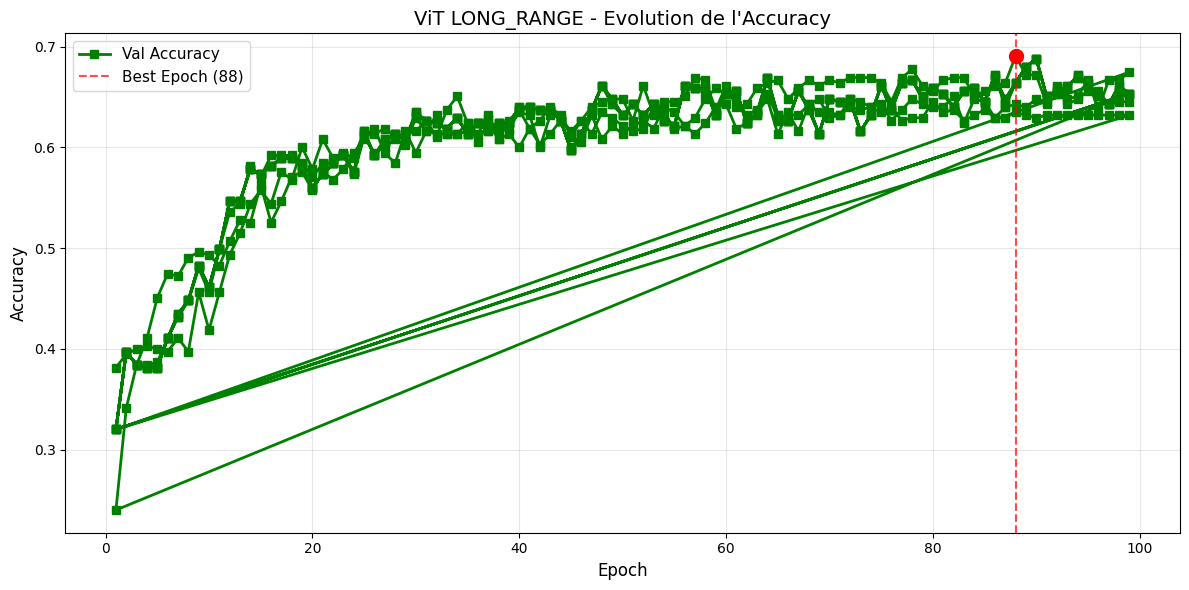


=== Evolution Accuracy ===
Best Val Accuracy: 0.6907
Best Epoch: 88
Total epochs entraînés: 693
Accuracy finale: 0.6453


In [ ]:
with open("confusion_matrices_long_range.json") as f:
    data = json.load(f)

# ============================================================
# EXTRAIRE L'HISTORIQUE ET CALCULER LES ACCURACIES
# ============================================================
epochs = []
val_accs = []

for entry in data:
    epoch = entry["epoch"]
    val_cm = np.array(entry["val"])
    
    # Calculer accuracy à partir de la matrice de confusion
    if val_cm.sum() > 0:
        val_acc = val_cm.diagonal().sum() / val_cm.sum()
        epochs.append(epoch)
        val_accs.append(val_acc)

# ============================================================
# TROUVER LA MEILLEURE EPOCH
# ============================================================
best_idx = np.argmax(val_accs)
best_epoch = epochs[best_idx]
best_val_acc = val_accs[best_idx]

# ============================================================
# CREER LE GRAPHIQUE
# ============================================================
plt.figure(figsize=(12, 6))
# ViT n'a que validation accuracy (pas de train_acc stockée)
plt.plot(epochs, val_accs, marker='s', label='Val Accuracy', linewidth=2, color='green')

# Mettre en évidence la meilleure epoch
plt.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
plt.scatter([best_epoch], [best_val_acc], color='red', s=100, zorder=5)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title(f"ViT LONG_RANGE - Evolution de l'Accuracy", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# AFFICHER LES STATISTIQUES
# ============================================================
print(f"\n=== Evolution Accuracy ===")
print(f"Best Val Accuracy: {best_val_acc:.4f}")
print(f"Best Epoch: {best_epoch}")
print(f"Total epochs entraînés: {len(epochs)}")
print(f"Accuracy finale: {val_accs[-1]:.4f}")

## 3. Recapitulatif de toutes les métriques

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ============================================================
# TEST 1: Load and parse JSON files
# ============================================================
def test_load_json_files():
    """Verify JSON files can be loaded without errors"""
    print("=" * 60)
    print("TEST 1: Loading JSON files")
    print("=" * 60)
    
    json_files = [
        "test_confusion_matrix_texture.json",
        "test_confusion_matrix_long_range.json",
        "confusion_matrices_texture.json",
        "confusion_matrices_long_range.json"
    ]
    
    for json_file in json_files:
        try:
            if Path(json_file).exists():
                with open(json_file, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                print(f"✅ {json_file}: LOADED")
                print(f"   Keys: {list(data.keys())}")
            else:
                print(f"⚠️  {json_file}: NOT FOUND (skipping)")
        except json.JSONDecodeError as e:
            print(f"❌ {json_file}: JSON ERROR - {e}")
        except Exception as e:
            print(f"❌ {json_file}: ERROR - {e}")
    
    print()

# ============================================================
# TEST 2: Validate confusion matrix structure
# ============================================================
def test_confusion_matrix_structure():
    """Verify confusion matrices have correct shape and values"""
    print("=" * 60)
    print("TEST 2: Validating Confusion Matrix Structure")
    print("=" * 60)
    
    datasets = {
        "test_confusion_matrix_texture.json": "texture",
        "test_confusion_matrix_long_range.json": "long_range"
    }
    
    for json_file, dataset_name in datasets.items():
        try:
            if not Path(json_file).exists():
                print(f"⚠️  {json_file}: NOT FOUND (skipping)")
                continue
                
            with open(json_file, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            key = f"{dataset_name}_confusion_matrix"
            
            if key in data:
                cm = np.array(data[key])
                
                # Validate shape
                assert cm.ndim == 2, f"Expected 2D matrix, got {cm.ndim}D"
                assert cm.shape[0] == cm.shape[1], "Matrix must be square"
                
                # Validate all values are non-negative
                assert np.all(cm >= 0), "All values must be non-negative"
                
                # Calculate metrics
                total_samples = cm.sum()
                diagonal_sum = cm.diagonal().sum()
                accuracy = diagonal_sum / total_samples if total_samples > 0 else 0
                
                print(f"✅ {dataset_name.upper()}:")
                print(f"   Shape: {cm.shape}")
                print(f"   Total samples: {int(total_samples)}")
                print(f"   Diagonal (correct): {int(diagonal_sum)}")
                print(f"   Accuracy: {accuracy:.4f}")
            else:
                print(f"❌ {json_file}: Key '{key}' not found")
        
        except Exception as e:
            print(f"❌ {json_file}: ERROR - {e}")
    
    print()

# ============================================================
# TEST 3: Plot confusion matrices from test files
# ============================================================
def plot_confusion_matrix_from_test(json_path, matrix_key, title, filename_suffix):
    """Plot confusion matrix from test JSON files"""
    try:
        if not Path(json_path).exists():
            print(f"⚠️  {json_path} not found, skipping...")
            return False
        
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        if matrix_key not in data:
            print(f"❌ Key '{matrix_key}' not found in {json_path}")
            return False
        
        cm = np.array(data[matrix_key])
        
        # Remove empty rows/cols (if any)
        non_empty_rows = ~(cm == 0).all(axis=1)
        non_empty_cols = ~(cm == 0).all(axis=0)
        cm_trimmed = cm[non_empty_rows][:, non_empty_cols]
        
        num_classes = cm_trimmed.shape[0]
        class_names = [str(i) for i in range(num_classes)]
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm_trimmed, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Nombre de prédictions'},
            square=True
        )
        
        plt.title(f'Matrice de Confusion (Test) - {title}', fontsize=14, fontweight='bold')
        plt.xlabel('Classe Prédite', fontsize=12)
        plt.ylabel('Classe Réelle', fontsize=12)
        plt.tight_layout()
        plt.savefig(f'confusion_matrix_{filename_suffix}.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"✅ Saved: confusion_matrix_{filename_suffix}.png")
        return True
    
    except Exception as e:
        print(f"❌ Error plotting {json_path}: {e}")
        return False

def test_plot_test_confusion_matrices():
    """Generate confusion matrix plots from test files"""
    print("=" * 60)
    print("TEST 3: Generating Confusion Matrix Plots")
    print("=" * 60)
    
    test_configs = [
        ("test_confusion_matrix_texture.json", "texture_confusion_matrix", "Texture (Test)", "vit_test_texture"),
        ("test_confusion_matrix_long_range.json", "long_range_confusion_matrix", "Long-Range (Test)", "vit_test_long_range")
    ]
    
    for json_file, matrix_key, title, suffix in test_configs:
        success = plot_confusion_matrix_from_test(json_file, matrix_key, title, suffix)
        if not success:
            print(f"⚠️  Skipped: {json_file}")
    
    print()

# ============================================================
# TEST 4: Compare CNN vs ViT metrics
# ============================================================
def test_compare_cnn_vit_metrics():
    """Compare metrics between CNN and ViT models"""
    print("=" * 60)
    print("TEST 4: Comparing CNN vs ViT Metrics")
    print("=" * 60)
    
    try:
        # Load CNN metrics
        cnn_files = {
            "texture": "cnn_texture_results.json",
            "long_range": "cnn_long_range_results.json"
        }
        
        # Load ViT metrics
        vit_files = {
            "texture": "vit_texture_results.json",
            "long_range": "vit_long_range_results.json"
        }
        
        for dataset_name in ["texture", "long_range"]:
            print(f"\n--- Dataset: {dataset_name.upper()} ---")
            
            cnn_file = cnn_files[dataset_name]
            vit_file = vit_files[dataset_name]
            
            cnn_exists = Path(cnn_file).exists()
            vit_exists = Path(vit_file).exists()
            
            if cnn_exists:
                with open(cnn_file, 'r') as f:
                    cnn_data = json.load(f)
                cnn_acc = cnn_data.get("best_val_acc", "N/A")
                cnn_f1 = cnn_data.get("best_val_f1", "N/A")
                cnn_epoch = cnn_data.get("best_epoch", "N/A")
                print(f"CNN  | Acc: {cnn_acc:.4f} | F1: {cnn_f1:.4f} | Epoch: {cnn_epoch}")
            else:
                print(f"⚠️  CNN file not found: {cnn_file}")
            
            if vit_exists:
                with open(vit_file, 'r') as f:
                    vit_data = json.load(f)
                vit_acc = vit_data.get("best_val_acc", "N/A")
                vit_f1 = vit_data.get("best_val_f1", "N/A")
                vit_epoch = vit_data.get("best_epoch", "N/A")
                print(f"ViT  | Acc: {vit_acc:.4f} | F1: {vit_f1:.4f} | Epoch: {vit_epoch}")
            else:
                print(f"⚠️  ViT file not found: {vit_file}")
    
    except Exception as e:
        print(f"❌ Error comparing metrics: {e}")
    
    print()

# ============================================================
# TEST 5: Extract and display per-class metrics
# ============================================================
def test_extract_per_class_metrics(json_path, dataset_type="cnn"):
    """Extract and display per-class metrics from results"""
    print("=" * 60)
    print(f"TEST 5: Per-Class Metrics ({json_path})")
    print("=" * 60)
    
    try:
        if not Path(json_path).exists():
            print(f"⚠️  {json_path} not found")
            return
        
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        print(f"Model: {data.get('model', 'N/A')}")
        print(f"Dataset: {data.get('dataset', 'N/A')}")
        print(f"Best Epoch: {data.get('best_epoch', 'N/A')}")
        print(f"Best Val Accuracy: {data.get('best_val_acc', 'N/A'):.4f}")
        print(f"Best Val F1: {data.get('best_val_f1', 'N/A'):.4f}")
        print()
        
        per_class = data.get('per_class_metrics', {})
        
        if per_class:
            print("Per-Class Metrics:")
            print("-" * 80)
            print(f"{'Class':<10} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Support':<10}")
            print("-" * 80)
            
            precisions, recalls, f1s = [], [], []
            
            for class_name, metrics in per_class.items():
                p = metrics['precision']
                r = metrics['recall']
                f1 = metrics['f1']
                support = metrics['support']
                
                precisions.append(p)
                recalls.append(r)
                f1s.append(f1)
                
                print(f"{class_name:<10} {p:<12.4f} {r:<12.4f} {f1:<12.4f} {support:<10}")
            
            print("-" * 80)
            print(f"{'MACRO':<10} {np.mean(precisions):<12.4f} {np.mean(recalls):<12.4f} {np.mean(f1s):<12.4f}")
            print()
        else:
            print("❌ No per-class metrics found")
    
    except Exception as e:
        print(f"❌ Error: {e}")
    
    print()

# ============================================================
# Unified function to display confusion matrices
# ============================================================
def display_all_confusion_matrices():
    """Display all confusion matrices (CNN and ViT)"""
    print("\n" + "=" * 60)
    print("DISPLAYING ALL CONFUSION MATRICES")
    print("=" * 60 + "\n")
    
    # Test confusion matrices (from test evaluation)
    test_configs = [
        ("test_confusion_matrix_texture.json", "texture_confusion_matrix", "CNN - Texture (Test)", "cnn_test_texture"),
        ("test_confusion_matrix_long_range.json", "long_range_confusion_matrix", "CNN - Long-Range (Test)", "cnn_test_long_range")
    ]
    
    for json_file, matrix_key, title, suffix in test_configs:
        plot_confusion_matrix_from_test(json_file, matrix_key, title, suffix)
    
    # Training confusion matrices (best epoch)
    print("\n🔄 Plotting training confusion matrices...\n")
    
    training_configs = [
        ("confusion_matrices_texture.json", "Texture (Best Epoch)", "vit_train_texture"),
        ("confusion_matrices_long_range.json", "Long-Range (Best Epoch)", "vit_train_long_range")
    ]
    
    for json_file, title, suffix in training_configs:
        try:
            if not Path(json_file).exists():
                print(f"⚠️  {json_file} not found")
                continue
            
            with open(json_file, 'r') as f:
                data = json.load(f)
            
            # Find best epoch
            best_acc, best_cm, best_epoch = 0, None, None
            for entry in data:
                cm = np.array(entry["val"])
                acc = cm.diagonal().sum() / cm.sum() if cm.sum() > 0 else 0
                if acc > best_acc:
                    best_acc, best_cm, best_epoch = acc, cm, entry["epoch"]
            
            if best_cm is not None:
                num_classes = best_cm.shape[0]
                class_names = [str(i) for i in range(num_classes)]
                
                plt.figure(figsize=(8, 6))
                sns.heatmap(
                    best_cm,
                    annot=True,
                    fmt='d',
                    cmap='Greens',
                    xticklabels=class_names,
                    yticklabels=class_names,
                    cbar_kws={'label': 'Count'},
                    square=True
                )
                
                plt.title(f'ViT - {title} (Epoch {best_epoch}, Acc: {best_acc:.4f})', 
                         fontsize=14, fontweight='bold')
                plt.xlabel('Predicted Class', fontsize=12)
                plt.ylabel('True Class', fontsize=12)
                plt.tight_layout()
                plt.savefig(f'confusion_matrix_{suffix}.png', dpi=300, bbox_inches='tight')
                plt.close()
                
                print(f"✅ Saved: confusion_matrix_{suffix}.png")
        
        except Exception as e:
            print(f"❌ Error processing {json_file}: {e}")

# ============================================================
# RUN ALL TESTS
# ============================================================
if __name__ == "__main__":
    print("\n🧪 RUNNING ALL TESTS FOR TP_VIT\n")
    
    test_load_json_files()
    test_confusion_matrix_structure()
    test_plot_test_confusion_matrices()
    test_compare_cnn_vit_metrics()
    test_extract_per_class_metrics("cnn_texture_results.json", "cnn")
    test_extract_per_class_metrics("cnn_long_range_results.json", "cnn")
    
    # Display all confusion matrices
    display_all_confusion_matrices()
    
    print("\n✅ ALL TESTS COMPLETED!\n")